In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import imblearn #should be install globally
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import ExtraTreesClassifier
from mlxtend.classifier import EnsembleVoteClassifier
from sklearn.metrics import auc,roc_auc_score,roc_curve
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier

from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams["figure.figsize"] = (10,5)

from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.compose import ColumnTransformer
from joblib import dump
from joblib import load
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer

In [2]:
random_state = 42

In [3]:
#data_path = "processed_data/rfs16.csv"
data_path = "data/outliers-none.csv"

data = pd.read_csv(data_path)
mrg_data_formatted = pd.read_csv("data/merged_formatted.csv")


In [4]:
data.head(5)

,AKT1,MGMT,PTEN,Outcome
0,6,1,48,1
1,10,2,53,1
2,6,7,33,0
3,8,9,56,0
4,5,0,34,1


In [5]:
mrg_data = mrg_data_formatted

In [7]:
data.columns

Index(['AKT1', 'MGMT', 'PTEN', 'Outcome'], dtype='object')

In [8]:
mrg_data.columns

Index(['SEC24B-AS1', 'A1BG', 'A1CF', 'GGACT', 'A2M', 'A2ML1', 'A2MP1',
       'A4GALT', 'A4GNT', 'AAAS',
       ...
       'ERCC-00031', 'ERCC-00042', 'ERCC-00069', 'ERCC-00084', 'ERCC-00097',
       'ERCC-00112', 'ERCC-00131', 'ERCC-00136', 'ERCC-00157', 'ERCC-00171'],
      dtype='object', length=20784)

In [9]:
#data splitting Pipeline,  labels and features
cols_labels = data.columns.tolist()
cols_labels.pop(-1)

'Outcome'

In [10]:
mrg_data_formatted.head(5)

,SEC24B-AS1,A1BG,A1CF,GGACT,A2M,A2ML1,A2MP1,A4GALT,A4GNT,AAAS,...,ERCC-00031,ERCC-00042,ERCC-00069,ERCC-00084,ERCC-00097,ERCC-00112,ERCC-00131,ERCC-00136,ERCC-00157,ERCC-00171
0,2,2,0,5,13,0,0,0,0,61,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7,1,0,4,1,0,1,0,0,65,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,14,78,68,0,2185,0,1,76,0,447,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,3,0,3,1,0,2,0,0,49,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,3,0,0,3,0,0,1,1,69,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
data_features = pd.read_csv(data_path, usecols = cols_labels)
data_labels = pd.read_csv(data_path, usecols = ['Outcome'])

In [13]:
mrg_data_sel = mrg_data_formatted[cols_labels]

In [14]:
X = data_features
y = data_labels
#X = StandardScaler().fit_transform(X)

#X_scaled = StandardScaler().fit_transform(X)
#X = pd.DataFrame(X_scaled, columns=X.columns)

#mrg_data_scaled = StandardScaler().fit_transform(mrg_data)
#mrg_data = pd.DataFrame(mrg_data_scaled, columns = mrg_data.columns)


#X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state)

In [15]:
#scaler = StandardScaler()
#scaler = RobustScaler()

#n_quantiles=500,
scaler = QuantileTransformer( n_quantiles=1000, output_distribution='normal', random_state=42)

#scaler = MinMaxScaler()

mrg_data_scaled = scaler.fit_transform(mrg_data_sel)
#mrg_data_scaled = pd.DataFrame(mrg_data_scaled, columns=mrg_data.columns)

E:\WORK\MUI_DET\venv_name\lib\site-packages\sklearn\preprocessing\_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (134). n_quantiles is set to n_samples.
  warnings.warn(


In [16]:
X.columns

Index(['AKT1', 'MGMT', 'PTEN'], dtype='object')

In [17]:
#mrg_data.columns

In [18]:
# #.............................................................................................. SMOTE
#sm = SMOTE(sampling_strategy='minority', k_neighbors = 4,  random_state=random_state)
#X_train, y_train = sm.fit_resample(X_train, y_train)

In [19]:
print("X_train type: ", type(X_train))
print("X_train sahpe: ", X_train.shape)

X_train type:  <class 'pandas.core.frame.DataFrame'>
X_train sahpe:  (32, 3)


In [27]:
cols_labels

['AKT1', 'MGMT', 'PTEN']

In [30]:
#QuantileTransformer(output_distribution='normal', random_state=42)
pipeline = Pipeline([('preprocessor',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  cols_labels,
                                                 )])),
                ('model',
                ExtraTreesClassifier(n_estimators = 50,#10,
                                     max_depth = 15, #7,#3, #lower value increase regularization
                                     min_samples_split =15, #3,# 3,#3, #larger value large regularization
                                     min_samples_leaf = 2, #5,#5,#5,#larger value large regularization
                                     criterion = 'gini',
                                     random_state = random_state,
                                     n_jobs = -1)
              )])
print("-----test data evaluation------")
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

test_fpr, test_tpr, thresholds = roc_curve(y_test, y_pred)

print('Area under test auc {}'.format(auc(test_fpr, test_tpr)))

print(classification_report(y_test, y_pred))
print("---------------------------------------")
print("-------in-house data eval--------------")
y_pred = pipeline.predict(mrg_data_sel)
y_pred


-----test data evaluation------
Accuracy: 0.8888888888888888
Area under test auc 0.9
              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.80      1.00      0.89         4

    accuracy                           0.89         9
   macro avg       0.90      0.90      0.89         9
weighted avg       0.91      0.89      0.89         9

---------------------------------------
-------in-house data eval--------------


E:\WORK\MUI_DET\venv_name\lib\site-packages\sklearn\pipeline.py:405: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)


array([1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1], dtype=int64)

In [31]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['AKT1', 'MGMT', 'PTEN'])])),
                ('model',
                 ExtraTreesClassifier(max_depth=15, min_samples_leaf=2,
                                      min_samples_split=15, n_estimators=50,
                                      n_jobs=-1, random_state=42))])

In [33]:
y_pred = pipeline.predict(X_train)
print("Accuracy:",metrics.accuracy_score(y_train, y_pred))

test_fpr, test_tpr, thresholds = roc_curve(y_train, y_pred)

print('Area under test auc {}'.format(auc(test_fpr, test_tpr)))

print(classification_report(y_train, y_pred))


Accuracy: 0.90625
Area under test auc 0.90625
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        16
           1       0.93      0.88      0.90        16

    accuracy                           0.91        32
   macro avg       0.91      0.91      0.91        32
weighted avg       0.91      0.91      0.91        32



In [36]:
y_pred = pipeline.predict_proba(X_test)
y_pred

array([[0.65599449, 0.34400551],
       [0.53703382, 0.46296618],
       [0.38957486, 0.61042514],
       [0.40512751, 0.59487249],
       [0.30358242, 0.69641758],
       [0.4332687 , 0.5667313 ],
       [0.5914573 , 0.4085427 ],
       [0.46765565, 0.53234435],
       [0.52033771, 0.47966229]])

In [26]:
#................................................................................................merged data
y_pred = pipeline.predict(temp_data)
y_pred

NameError: name 'temp_data' is not defined

In [ ]:
#############################################################################################################################

In [42]:
y_pred = pipeline.predict_proba(temp_data)
y_pred

array([[0.47096542, 0.52903458],
       [0.477597  , 0.522403  ],
       [0.48721542, 0.51278458],
       [0.46496542, 0.53503458],
       [0.44496542, 0.55503458],
       [0.51026366, 0.48973634],
       [0.46496542, 0.53503458],
       [0.47096542, 0.52903458],
       [0.46496542, 0.53503458],
       [0.46496542, 0.53503458],
       [0.47829875, 0.52170125],
       [0.48429875, 0.51570125],
       [0.44496542, 0.55503458],
       [0.46496542, 0.53503458],
       [0.46496542, 0.53503458],
       [0.44496542, 0.55503458],
       [0.44496542, 0.55503458],
       [0.44496542, 0.55503458],
       [0.44496542, 0.55503458],
       [0.44496542, 0.55503458],
       [0.46496542, 0.53503458],
       [0.46496542, 0.53503458],
       [0.44496542, 0.55503458],
       [0.46496542, 0.53503458],
       [0.50426366, 0.49573634],
       [0.44496542, 0.55503458],
       [0.47563208, 0.52436792],
       [0.49693033, 0.50306967],
       [0.48496542, 0.51503458],
       [0.51693033, 0.48306967],
       [0.

Text(341.5833333333334, 0.5, 'predicted labels')

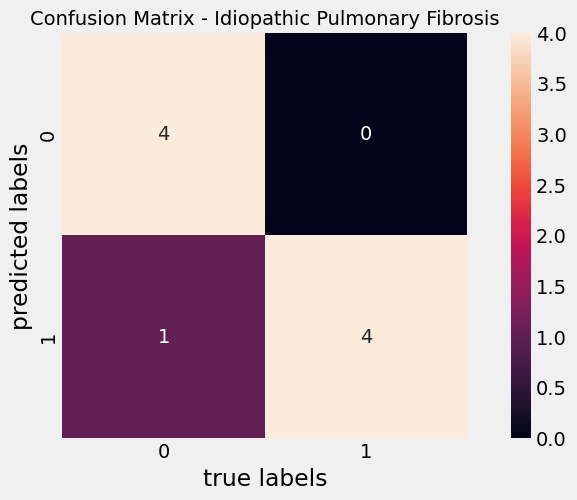

In [37]:
y_pred = pipeline.predict(X_test)
mat = confusion_matrix(y_test, y_pred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=True,
           xticklabels = '01', yticklabels = '01')

plt.title('Confusion Matrix - Idiopathic Pulmonary Fibrosis', fontsize=14, color='black')
plt.xlabel('true labels')
plt.ylabel('predicted labels')

In [44]:
y_pred = pipeline.predict(temp_data_formatted)
y_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0], dtype=int64)

In [27]:
y_pred = pipeline.predict(temp_data_formatted_scaled)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int64)

In [28]:
###################################################################################################################

In [29]:
pipeline.named_steps['preprocessor'].named_transformers_['standardscaler'].fit_transform(X_train)

KeyError: 'standardscaler'

In [43]:
y_pred = pipeline.predict(temp_data)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=int64)

In [44]:
y_pred = pipeline.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

test_fpr, test_tpr, thresholds = roc_curve(y_test, y_pred)

print('Area under test auc {}'.format(auc(test_fpr, test_tpr)))

print(classification_report(y_test, y_pred))


Accuracy: 1.0
Area under test auc 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         4

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



In [45]:
y_pred = pipeline.predict(X_train)
print("Accuracy:",metrics.accuracy_score(y_train, y_pred))

test_fpr, test_tpr, thresholds = roc_curve(y_train, y_pred)

print('Area under test auc {}'.format(auc(test_fpr, test_tpr)))

print(classification_report(y_train, y_pred))


Accuracy: 0.9583333333333334
Area under test auc 0.9583333333333333
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.92      1.00      0.96        12

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



In [90]:
################################################################################################################################

In [91]:
mat = confusion_matrix(y_test, y_pred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=True,
           xticklabels = '01', yticklabels = '01')

plt.title('adaboost', fontsize=18, color='black')
plt.xlabel('true labels')
plt.ylabel('predicted labels')

ValueError: Found input variables with inconsistent numbers of samples: [7, 24]

In [16]:
###########################################################################################################################

In [17]:
###########################################################################################################################

In [38]:
import pickle
with open('pipeline_pickle_glioblastome-multifome_sajjadalikhan_3features__90test-90train_standardScaler-regularized.pkl', 'wb') as pipe: 
    pickle.dump(pipeline, pipe)

In [37]:
with open('pipeline_pickle_diffuse-large-b-cell-lymphoma_sajjadalikhan_6features__93test-95train_standardScaler-regularized.pkl', 'rb') as file:
    model = pickle.load(file)

In [38]:
loaded_pipeline = model

In [39]:
loaded_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['IKBKG', 'GAB3', 'DKC1',
                                                   'FUNDC2', 'RAB39B',
                                                   'IL9R'])])),
                ('model',
                 ExtraTreesClassifier(max_depth=7, min_samples_leaf=7,
                                      min_samples_split=7, n_estimators=50,
                                      n_jobs=-1, random_state=42))])

In [40]:
y_pred = pipeline.predict(X_train)
print("Accuracy:",metrics.accuracy_score(y_train, y_pred))

test_fpr, test_tpr, thresholds = roc_curve(y_train, y_pred)

print('Area under test auc {}'.format(auc(test_fpr, test_tpr)))

print(classification_report(y_train, y_pred))

Accuracy: 1.0
Area under test auc 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         7

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



In [47]:
#########################################################################################################################

In [51]:
#data_path = "processed_data/Combined_1_2.csv"
data_path = "merged.csv"
data = pd.read_csv(data_path).T
data.shape
X_test = data

In [39]:
#data splitting Pipeline,  labels and features
cols_labels = data.columns.tolist()
cols_labels.pop(-1)
data_features = pd.read_csv(data_path, usecols = cols_labels)
data_labels = pd.read_csv(data_path, usecols = ['Outcomes'])1

In [31]:
X = data_features
y = data_labels

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [49]:
#loaded_pipeline = load('pipeline_UveitisDisease_SajjadAliKhan_inHouse.pkl')
loaded_pipeline = model


In [52]:
y_pred = loaded_pipeline.predict(X_test)


KeyError: "None of [Index(['ZFP36L2', 'CX3CR1', 'SLC12A7', 'GIMAP4', 'A2M', 'FMN1', 'IQGAP1',\n       'MTRNR2L10'],\n      dtype='object')] are in the [columns]"

In [34]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

test_fpr, test_tpr, thresholds = roc_curve(y_test, y_pred)

print('Area under test auc {}'.format(auc(test_fpr, test_tpr)))

print(classification_report(y_test, y_pred))


Accuracy: 1.0
Area under test auc 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         4

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



In [35]:
y_pred = loaded_pipeline.predict(X_train)
print("Accuracy:",metrics.accuracy_score(y_train, y_pred))

test_fpr, test_tpr, thresholds = roc_curve(y_train, y_pred)

print('Area under test auc {}'.format(auc(test_fpr, test_tpr)))

print(classification_report(y_train, y_pred))



Accuracy: 0.9583333333333334
Area under test auc 0.9583333333333333
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.92      1.00      0.96        12

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



In [36]:
########################################################3333##################################################################33

In [ ]:
-------------------------Extras---------------------

In [ ]:
'''
pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['WSB1', 'CD200R1', 'TLR10',
                                                   'CD180', 'HCP5', 'HSPA5',
                                                   'CPT1A', 'DDX17'])])),
                ('model',
                 VotingClassifier(estimators=[('ExtraTreesClassifier',
                                               ExtraTreesClassifier()),
                                              ('SVC',
                                               SVC(C=1, gamma='auto',
                                                   probability=True))]))])
'''


#house10
'''
pipeline = Pipeline([('preprocessor',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['IL1B','METTL7A','WSB1','NAV1','CD200R1',
                                                     'TLR10','CD180','HSPA5','CPT1A','DDX17'])])),
                ('model',
                 VotingClassifier(estimators=[('ExtraTreesClassifier',
                                               ExtraTreesClassifier(n_estimators = 400,
                                                                     max_depth = 31,
                                                                     min_samples_split = 6,
                                                                     min_samples_leaf = 3,
                                                                     criterion = 'gini',
                                                                     random_state = 42,
                                                                     n_jobs = -1) ),
                                              ('SVC',
                                               SVC(C=1, gamma=1,
                                                   probability=True,
                                                  random_state=42))]))])
pipeline.fit(X_train, y_train)
'''

#house7

# pipeline = Pipeline([('preprocessor',
#                  ColumnTransformer(transformers=[('standardscaler',
#                                                   StandardScaler(),
#                                                   ['WSB1', 'CD200R1', 'TLR10',
#                                                    'CD180', 'HSPA5',
#                                                    'CPT1A', 'DDX17'])])),
#                 ('model',
#                  VotingClassifier(estimators=[('ExtraTreesClassifier',
#                                                ExtraTreesClassifier(n_estimators = 400,
#                                                                      max_depth = 11, #lower value increase regularization
#                                                                      min_samples_split = 12, #larger value large regularization
#                                                                      min_samples_leaf = 6,#larger value large regularization
#                                                                      criterion = 'gini',
#                                                                      random_state = 42,
#                                                                      n_jobs = -1)
#                                               ),
#                                               ('SVC',
#                                                SVC(C=0.1, gamma=1 , #C1, g'auto' 
#                                                    probability=True))], voting='soft'))])
'''
# Define the features you want to select and scale
selected_features = ['ZFP36L2', 'CX3CR1', 'SLC12A7', 'GIMAP4', 'A2M', 'FMN1', 'IQGAP1', 'MTRNR2L10']

# Create a ColumnTransformer to select and scale the specified features
preprocessor = ColumnTransformer(
    transformers=[
        ('standardscaler', StandardScaler(), selected_features)
    ])

# Create the final pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ExtraTreesClassifier(
        n_estimators=20,
        max_depth=25,
        min_samples_split=3,
        min_samples_leaf=5,
        criterion='gini',
        random_state=random_state,
        n_jobs=-1
    ))
])
'''

In [ ]:
# #PIPELINE
# # Define the feature names you want to select
# selected_features = ['WSB1', 'CD200R1', 'TLR10', 'CD180', 'HCP5', 'HSPA5', 'CPT1A', 'DDX17']

# # Create a ColumnTransformer for feature scaling
# preprocessor = make_column_transformer(
#     (StandardScaler(), selected_features),  # StandardScaler for selected features
# )

# steps = [
#     ('preprocessor', preprocessor),  # Step 1: Feature scaling
#     ('model', VotingClassifier(estimators=[
#         ('ExtraTreesClassifier', ExtraTreesClassifier()),
#         ('SVC', SVC(gamma='auto', probability=True, C=1))
#     ], voting='hard'))  # Step 2: Model Training
# ]
